<a href="https://colab.research.google.com/github/vish9571/Quantium_Sales/blob/data-cleaning/ET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- STATISTICAL T-TEST ---
T-Statistic: 37.8320, P-Value: 1.1178e-309
Insight: Mainstream young/mid-age singles and couples pay significantly MORE per unit than budget/premium customers.

--- AFFINITY ANALYSIS ---

Top 5 Brand Affinities:
BRAND
TYRRELLS    1.228095
TWISTIES    1.219319
DORITOS     1.214553
KETTLE      1.195897
TOSTITOS    1.195713
Name: PROD_QTY, dtype: float64

Top 5 Pack Size Affinities:
PACK_SIZE
270.0    1.268287
380.0    1.257030
330.0    1.221717
134.0    1.186670
110.0    1.183637
Name: PROD_QTY, dtype: float64


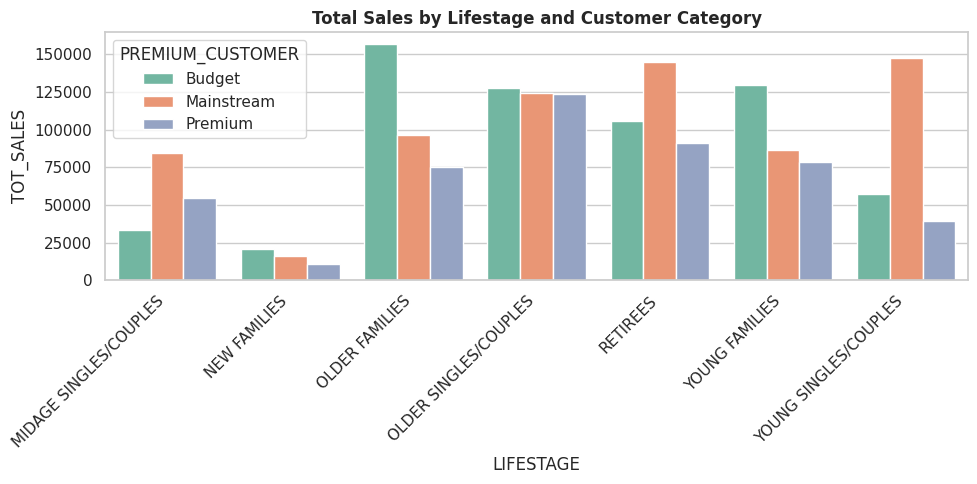

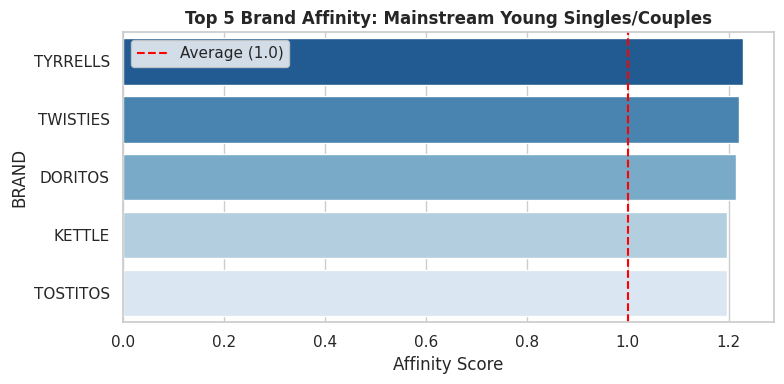

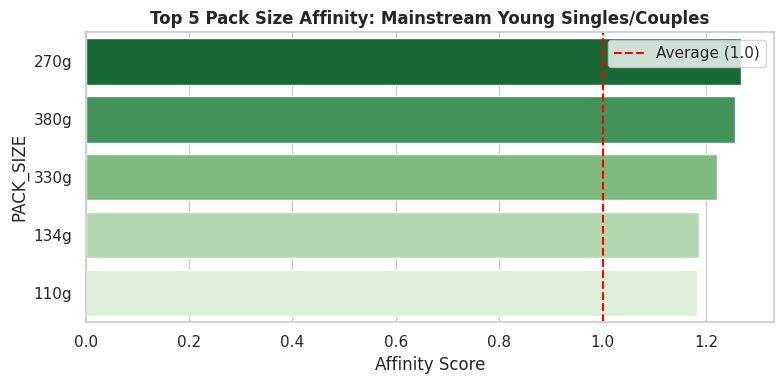

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


# load in the transaction and customer data
txn_data = pd.read_csv('/QVI_transaction_data.csv')
cust_data = pd.read_csv('/QVI_purchase_behaviour.csv')

# fix the dates (excel format to datetime)
txn_data['DATE'] = pd.to_datetime(txn_data['DATE'], origin='1899-12-30', unit='D')

# pull out pack sizes and brand names from the product name column
txn_data['PACK_SIZE'] = txn_data['PROD_NAME'].str.extract(r'(\d+)').astype(float)
txn_data['BRAND'] = txn_data['PROD_NAME'].str.split().str[0].str.upper()

# standardize the brand names so they group correctly
brand_mapping = {
    'RED': 'RRD', 'SNBTS': 'SUNBITES', 'INFZNS': 'INFUZIONS',
    'WW': 'WOOLWORTHS', 'SMITH': 'SMITHS', 'NCC': 'NATURAL',
    'DORITO': 'DORITOS', 'GRAIN': 'GRNWVES'
}
txn_data['BRAND'] = txn_data['BRAND'].replace(brand_mapping)

# drop salsa items and the 200-pack outlier
txn_data = txn_data[~txn_data['PROD_NAME'].str.lower().str.contains('salsa')]
txn_data = txn_data[txn_data['PROD_QTY'] < 200]

# join the tables and calculate price per unit
data = pd.merge(txn_data, cust_data, on='LYLTY_CARD_NBR', how='left')
data['PRICE_PER_UNIT'] = data['TOT_SALES'] / data['PROD_QTY']


# check if mainstream young/mid-age singles & couples pay more per unit
print("\n--- STATISTICAL T-TEST ---")

mainstream = data[(data['PREMIUM_CUSTOMER'] == 'Mainstream') &
                  (data['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']))]['PRICE_PER_UNIT']

budget_premium = data[(data['PREMIUM_CUSTOMER'].isin(['Budget', 'Premium'])) &
                      (data['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']))]['PRICE_PER_UNIT']

t_stat, p_value = stats.ttest_ind(mainstream, budget_premium, alternative='greater')
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Insight: Mainstream young/mid-age singles and couples pay significantly MORE per unit than budget/premium customers.")
else:
    print("Insight: No significant difference in unit price.")


# find out what brands and pack sizes our target segment prefers
print("\n--- AFFINITY ANALYSIS ---")

target_segment = data[(data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (data['PREMIUM_CUSTOMER'] == 'Mainstream')]
other_segment = data[~((data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (data['PREMIUM_CUSTOMER'] == 'Mainstream'))]

# brand affinity
target_brand_prop = target_segment.groupby('BRAND')['PROD_QTY'].sum() / target_segment['PROD_QTY'].sum()
other_brand_prop = other_segment.groupby('BRAND')['PROD_QTY'].sum() / other_segment['PROD_QTY'].sum()
brand_affinity = (target_brand_prop / other_brand_prop).sort_values(ascending=False)

print("\nTop 5 Brand Affinities:")
print(brand_affinity.head())

# pack size affinity
target_pack_prop = target_segment.groupby('PACK_SIZE')['PROD_QTY'].sum() / target_segment['PROD_QTY'].sum()
other_pack_prop = other_segment.groupby('PACK_SIZE')['PROD_QTY'].sum() / other_segment['PROD_QTY'].sum()
pack_affinity = (target_pack_prop / other_pack_prop).sort_values(ascending=False)

print("\nTop 5 Pack Size Affinities:")
print(pack_affinity.head())


# create the charts for the final report
# 1. total sales bar chart
plt.figure(figsize=(10, 5))
sales_by_segment = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sns.barplot(data=sales_by_segment, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER', palette='Set2')
plt.title('Total Sales by Lifestage and Customer Category', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. top brands affinity chart
plt.figure(figsize=(8, 4))
top_brands = brand_affinity.head(5)
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette='Blues_r', legend=False)
plt.axvline(x=1.0, color='red', linestyle='--', label='Average (1.0)')
plt.title('Top 5 Brand Affinity: Mainstream Young Singles/Couples', fontweight='bold')
plt.xlabel('Affinity Score')
plt.legend()
plt.tight_layout()
plt.show()

# 3. top pack sizes affinity chart
plt.figure(figsize=(8, 4))
top_packs = pack_affinity.head(5)
pack_labels = top_packs.index.astype(int).astype(str) + 'g'
sns.barplot(x=top_packs.values, y=pack_labels, hue=pack_labels, palette='Greens_r', legend=False)
plt.axvline(x=1.0, color='red', linestyle='--', label='Average (1.0)')
plt.title('Top 5 Pack Size Affinity: Mainstream Young Singles/Couples', fontweight='bold')
plt.xlabel('Affinity Score')
plt.legend()
plt.tight_layout()
plt.show()